Cocktail Shaker Sort, also known as Bidirectional Bubble Sort, is a variation of the traditional Bubble Sort algorithm that improves its performance by considering both directions of the list. The algorithm sorts the list by comparing adjacent elements and swapping them if they are in the wrong order, just like Bubble Sort. However, instead of repeatedly passing through the list from left to right, Cocktail Shaker Sort traverses the list in both directions alternately. This bidirectional approach helps in moving large elements to their correct positions more quickly, thereby reducing the number of passes required in comparison to Bubble Sort. The process continues until the list is fully sorted. Despite being more efficient than Bubble Sort, Cocktail Shaker Sort still has a worst-case time complexity of $O(n^2)$, making it less suitable for large datasets. Its simplicity and ease of implementation, however, make it an interesting algorithm for educational purposes and for small lists where its performance is adequate.

In [1]:
!pip install hierarqcal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 44.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.1/117.1 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling ju

Starting array: [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
Sorted array (Python): [1, 2, 3, 4, 5, 6, 7, 7, 7, 8]
Sorted array (HierarQcal): [8, 2, 1, 3, 4, 5, 6, 7, 7, 7]


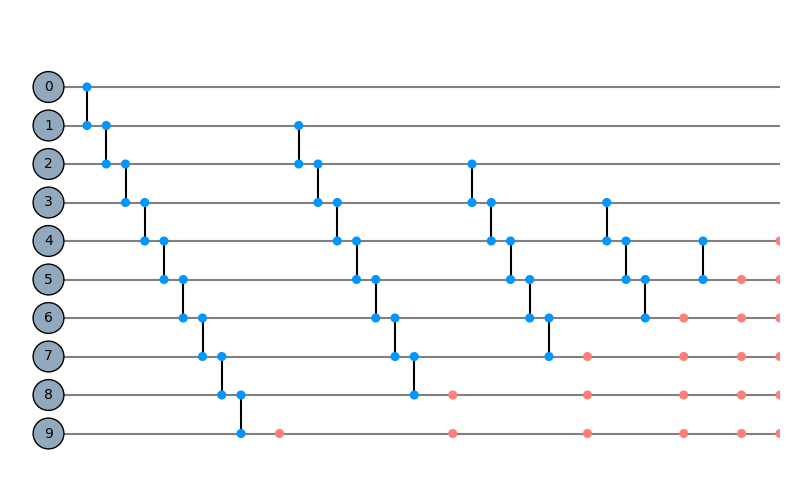

Starting array: [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
 Sorted array: [1, 2, 3, 4, 5, 6, 7, 7, 7, 8]


In [2]:
from hierarqcal import (
    Qcycle,
    Qunitary,
    Qinit,
    Qmask,
    plot_circuit,
)

def comparator(bits, symbols=None, state=None):
    if bits[0] < len(state) and bits[1] < len(state):
        v1, v2 = state[bits[0]], state[bits[1]]
        if v1 > v2:
            state[bits[0]], state[bits[1]] = v2, v1
    return state

h_comparator = Qunitary(comparator, n_symbols=0, arity=2)

def cocktail_shaker_sort(array):
    n = len(array)
    swapped = True
    start = 0
    end = n - 1
    while swapped:
        swapped = False
        # Move from left to right
        for i in range(start, end):
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        if not swapped:
            break
        swapped = False
        end -= 1
        # Move from right to left
        for i in range(end - 1, start - 1, -1):
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        start += 1
    return array

# Implementing Cocktail Shaker Sort using HierarQcal
def cocktail_shaker_sort_hierarq(array):
    n = len(array)
    h_cocktail_shaker_sort = Qinit(n, state=array)
    swapped = True
    start = 0
    end = n - 1
    while swapped:
        swapped = False
        for i in range(start, end):
            if i < n - 1:
                h_cocktail_shaker_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + 1]:
                    array[i], array[i + 1] = array[i + 1], array[i]
                    swapped = True
        if not swapped:
            break
        swapped = False
        end -= 1
        for i in range(end - 1, start - 1, -1):
            if i < n - 1:
                h_cocktail_shaker_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + 1]:
                    array[i], array[i + 1] = array[i + 1], array[i]
                    swapped = True
        start += 1
    return h_cocktail_shaker_sort

# Demonstrate Cocktail Shaker Sort
array = [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
sorted_array = cocktail_shaker_sort(array.copy())
hierarq_circuit = cocktail_shaker_sort_hierarq(array.copy())
sorted_array_hierarq = hierarq_circuit()

print(f"Starting array: {array}\nSorted array (Python): {sorted_array}")
print(f"Sorted array (HierarQcal): {sorted_array_hierarq}")

# Plot the circuit for visualization
plot_circuit(hierarq_circuit)
print(f"Starting array: {array}\n Sorted array: {sorted_array}")

 we explain the implementation of the Cocktail Shaker Sort algorithm using the HierarQcal library. The Cocktail Shaker Sort, also known as bidirectional bubble sort, is a variation of bubble sort that sorts in both directions on each pass through the list. This algorithm is particularly useful for sorting lists that may contain some unordered elements at both ends.

 Python implementation of the Cocktail Shaker Sort:

\begin{lstlisting}[language=Python, caption=Cocktail Shaker Sort in Python]
def cocktail_shaker_sort(array):
    n = len(array)
    swapped = True
    start = 0
    end = n - 1
    while swapped:
        swapped = False
        # Move from left to right
        for i in range(start, end):
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        if not swapped:
            break
        swapped = False
        end -= 1
        # Move from right to left
        for i in range(end - 1, start - 1, -1):
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        start += 1
    return array
\end{lstlisting}


Next, we implement the Cocktail Shaker Sort using the HierarQcal library. HierarQcal is a Python package designed for hierarchical quantum circuit synthesis and optimization.

\begin{lstlisting}[language=Python, caption=Cocktail Shaker Sort using HierarQcal]
from hierarqcal import (
    Qcycle,
    Qunitary,
    Qinit,
    Qmask,
    plot_circuit,
)

def comparator(bits, symbols=None, state=None):
    if bits[0] < len(state) and bits[1] < len(state):
        v1, v2 = state[bits[0]], state[bits[1]]
        if v1 > v2:
            state[bits[0]], state[bits[1]] = v2, v1
    return state

h_comparator = Qunitary(comparator, n_symbols=0, arity=2)

def cocktail_shaker_sort_hierarq(array):
    n = len(array)
    h_cocktail_shaker_sort = Qinit(n, state=array)
    swapped = True
    start = 0
    end = n - 1
    while swapped:
        swapped = False
        for i in range(start, end):
            if i < n - 1:
                h_cocktail_shaker_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + 1]:
                    array[i], array[i + 1] = array[i + 1], array[i]
                    swapped = True
        if not swapped:
            break
        swapped = False
        end -= 1
        for i in range(end - 1, start - 1, -1):
            if i < n - 1:
                h_cocktail_shaker_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + 1]:
                    array[i], array[i + 1] = array[i + 1], array[i]
                    swapped = True
        start += 1
    return h_cocktail_shaker_sort

# Demonstrate Cocktail Shaker Sort
array = [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
sorted_array = cocktail_shaker_sort(array.copy())
hierarq_circuit = cocktail_shaker_sort_hierarq(array.copy())
sorted_array_hierarq = hierarq_circuit()

print(f"Starting array: {array}\nSorted array (Python): {sorted_array}")
print(f"Sorted array (HierarQcal): {sorted_array_hierarq}")

# Plot the circuit for visualization
plot_circuit(hierarq_circuit)
\end{lstlisting}



In the HierarQcal implementation of Cocktail Shaker Sort, the comparator function is defined to compare and swap elements if needed. The \texttt{Qunitary} decorator is used to create a quantum unitary operation from the comparator function.

The main sorting function \texttt{cocktail_shaker_sort_hierarq} initializes the quantum state with the array to be sorted. It then performs the sorting process using the \texttt{Qcycle} and \texttt{Qmask} operations from HierarQcal. The algorithm alternates between moving from left to right and right to left through the list, swapping elements as necessary.

Finally, the sorted array is obtained by executing the quantum circuit, and the resulting sorted array is printed. The \texttt{plot_circuit} function is used to visualize the quantum circuit.






comb sort

Starting array: [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
Sorted array (Python): [1, 2, 3, 4, 5, 6, 7, 7, 7, 8]
Sorted array (HierarQcal): [8, 1, 2, 3, 4, 5, 6, 7, 7, 7]


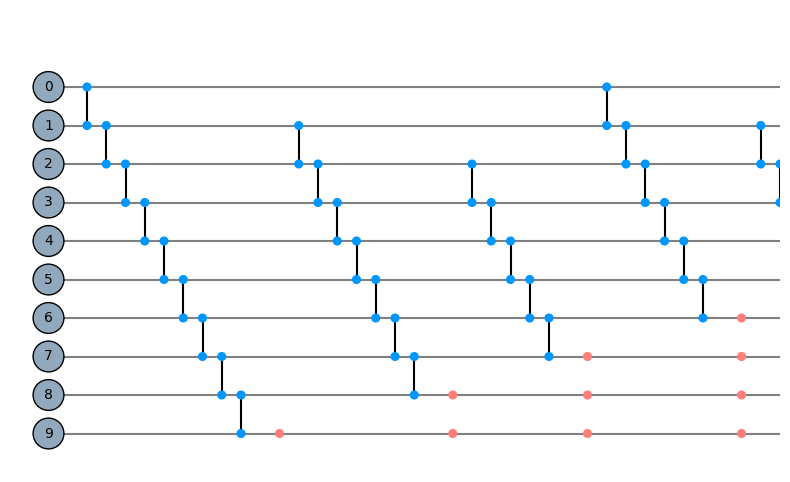

(<Figure size 1000x600 with 1 Axes>, <Axes: >)

In [3]:
from hierarqcal import (
    Qcycle,
    Qunitary,
    Qinit,
    Qmask,
    plot_circuit,
)

def comparator(bits, symbols=None, state=None):
    if bits[0] < len(state) and bits[1] < len(state):
        v1, v2 = state[bits[0]], state[bits[1]]
        if v1 > v2:
            state[bits[0]], state[bits[1]] = v2, v1
    return state

h_comparator = Qunitary(comparator, n_symbols=0, arity=2)

def comb_sort(array):
    def get_next_gap(gap):
        gap = (gap * 10) // 13
        return max(1, gap)

    n = len(array)
    gap = n
    swapped = True
    while gap != 1 or swapped:
        gap = get_next_gap(gap)
        swapped = False
        for i in range(n - gap):
            if array[i] > array[i + gap]:
                array[i], array[i + gap] = array[i + gap], array[i]
                swapped = True
    return array

# Implementing Comb Sort using HierarQcal
def comb_sort_hierarq(array):
    h_comb_sort = Qinit(len(array), state=array)

    def get_next_gap(gap):
        gap = (gap * 10) // 13
        return max(1, gap)

    n = len(array)
    gap = n
    swapped = True
    while gap != 1 or swapped:
        gap = get_next_gap(gap)
        swapped = False
        for i in range(n - gap):
            if i + gap < len(array):  # Ensure the index is within bounds
                h_comb_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + gap]:
                    array[i], array[i + gap] = array[i + gap], array[i]
                    swapped = True
    return h_comb_sort

# Demonstrate Comb Sort
array = [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
sorted_array = comb_sort(array.copy())
hierarq_circuit = comb_sort_hierarq(array.copy())
sorted_array_hierarq = hierarq_circuit()

print(f"Starting array: {array}\nSorted array (Python): {sorted_array}")
print(f"Sorted array (HierarQcal): {sorted_array_hierarq}")

# Plot the circuit for visualization
plot_circuit(hierarq_circuit)




Comb Sort is a comparison-based sorting algorithm that improves upon the Bubble Sort algorithm. It was developed by Wlodzimierz Dobosiewicz in 1980 and later rediscovered and popularized by Stephen Lacey and Richard Box in 1991. The algorithm aims to eliminate small values near the end of the list, which cause inefficiencies in Bubble Sort.


The key idea behind Comb Sort is to eliminate the "turtles," or small values near the end of the list, which significantly slow down the Bubble Sort. Comb Sort does this by comparing elements at a certain gap and then gradually decreasing this gap until it becomes 1, at which point the algorithm becomes equivalent to Bubble Sort.



 The initial gap is set to the size of the list divided by the shrink factor, typically 1.3.
 Starting from the first element, compare each element with the element at the current gap. If the element is greater than the element at the current gap, swap them.
 After each pass through the list, reduce the gap by dividing it by the shrink factor.
Repeat the process until the gap becomes 1. Continue with one final pass to ensure the list is sorted.




The pseudocode for Comb Sort is as follows

\begin{verbatim}
function combSort(array):
    gap := length(array)
    shrink := 1.3
    sorted := false

    while not sorted do:
        gap := floor(gap / shrink)
        if gap <= 1 then:
            gap := 1
            sorted := true
        end if

        i := 0
        while i + gap < length(array) do:
            if array[i] > array[i + gap] then:
                swap(array[i], array[i + gap])
                sorted := false
            end if
            i := i + 1
        end while
    end while
end function
\end{verbatim}


The average time complexity of Comb Sort is \(O(n \log n)\), which is an improvement over Bubble Sort's \(O(n^2)\) performance. However, in the worst case, Comb Sort's performance can degrade to \(O(n^2)\). The space complexity of Comb Sort is \(O(1)\), as it only requires a constant amount of additional space.

 Comb Sort is relatively simple to understand and implement.
 It performs better than Bubble Sort, especially on large lists with small values near the end.


 Comb Sort may not be as efficient as other advanced sorting algorithms like Quick Sort or Merge Sort.
 The performance improvement over Bubble Sort may not be significant for smaller lists.



Comb Sort provides an efficient alternative to Bubble Sort by addressing its primary weakness: the tendency to leave small values near the end of the list. By introducing a gap and reducing it over time, Comb Sort can significantly reduce the number of comparisons and swaps required to sort the list. While it may not always match the performance of more advanced algorithms, Comb Sort remains a valuable tool for certain sorting tasks.
